#### Final Project

**Name and UIN:** **Kaushik Sivakumar (936002746)**

#### Introduction

The objective of this project is to develop predictive models for the compressive strength of high-performance Concrete using Supervised Machine Learning techniques. The compressive strength of concrete is influenced by a variety of materials that are combined in specific proportions during the mix design.

The dataset includes 1030 samples of concrete compositions with 9 attributes measured for each sample:

Target Variable:
- Compressive Strength of Concrete, measued in MPa

Features:

- cement - Cement Content, measured in kg/m³ (real valued)
- slag - Blast Furnace Slag, measured in kg/m³ (real valued)
- ash - Fly Ash Content, measured in kg/m³ (real valued)
- water - Water Content, measured in kg/m³ (real valued)
- superplastic - Superplasticizer Content, measured in kg/m³ (real valued)
- coarseagg - Coarse Aggregate Content, measured in kg/m³ (real valued)
- fineagg - Fine Aggregate Content, measured in kg/m³ (real valued)
- age - Curing Time, in Days (1-365) (integer valued)

In [2958]:
#Importing Required Packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns

import statsmodels.api as sm
import sklearn.linear_model as skl
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

import scipy.stats as stats

from ISLP.models import (Stepwise,
                        sklearn_selected,
                        sklearn_selection_path)

from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     ShuffleSplit)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.discriminant_analysis import \
        (LinearDiscriminantAnalysis as LDA,
        QuadraticDiscriminantAnalysis as QDA)

from sklearn.metrics import accuracy_score

from ISLP import confusion_table

from functools import partial
from ISLP.models import sklearn_sm

from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score


import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

#### Reading the data into a dataframe object:

In [2230]:
cement_data = pd.read_csv('concrete.csv')

cement_data.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


#### Dimensions of the dataset:

In [2461]:
cement_data.shape

(1030, 9)

#### Checking the dataset for missing values as part of data cleaning:

In [2480]:
cement_data.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

There are no missing values, so data cleaning is not required, and imputation of missing data is unnecessary.

#### Getting dataset information, including the data types of each column:

In [2488]:
cement_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [2512]:
predictors = cement_data.columns.drop('strength')
response = 'strength'

print(f'Predictors: {str(predictors.tolist())[1:-1]}')
print(f"Response:   '{response}'")

Predictors: 'cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age'
Response:   'strength'


#### Generating descriptive statistics (mean, standard deviation, minimum, and maximum values) of each column in the dataset:

In [2454]:
input_data_stats = cement_data.describe().T.iloc[:,[1,2,3,7,0]]

input_data_stats['count'] = input_data_stats['count'].astype(int)
input_data_stats.style.format('{:.2f}')

,mean,std,min,max,count
cement,281.17,104.51,102.00,540.00,1030.00
slag,73.90,86.28,0.00,359.40,1030.00
ash,54.19,64.00,0.00,200.10,1030.00
water,181.57,21.35,121.80,247.00,1030.00
superplastic,6.20,5.97,0.00,32.20,1030.00
coarseagg,972.92,77.75,801.00,1145.00,1030.00
fineagg,773.58,80.18,594.00,992.60,1030.00
age,45.66,63.17,1.00,365.00,1030.00
strength,35.82,16.71,2.33,82.60,1030.00


Although all features, except 'age', are measured in units of density (kg/m³), there is significant variability between the predictors. For instance, cement content has a high variability (std = 104.51) compared to superplasticizers (std = 5.97).

Due to this variability, along with differing min and max values, we can expect the OLS regression models to produce smaller or larger slope coefficients depending on the predictors.

Additionally, since the 'age' predictor has different units from the other predictors, it needs to be standardized for regression and classification models that require standardization.

#### Counting the unique values in each column of the dataset:

In [218]:
for column in cement_data.columns:
    print(f"{column} has {len(cement_data[column].unique())} unique values")

cement has 278 unique values
slag has 185 unique values
ash has 156 unique values
water has 195 unique values
superplastic has 111 unique values
coarseagg has 284 unique values
fineagg has 302 unique values
age has 14 unique values
strength has 845 unique values


The 'age' predictor has only 14 unique values across 1,030 samples. A boxplot can be used to understand how the response varies with 'age'.

#### Generating the correlation matrix:

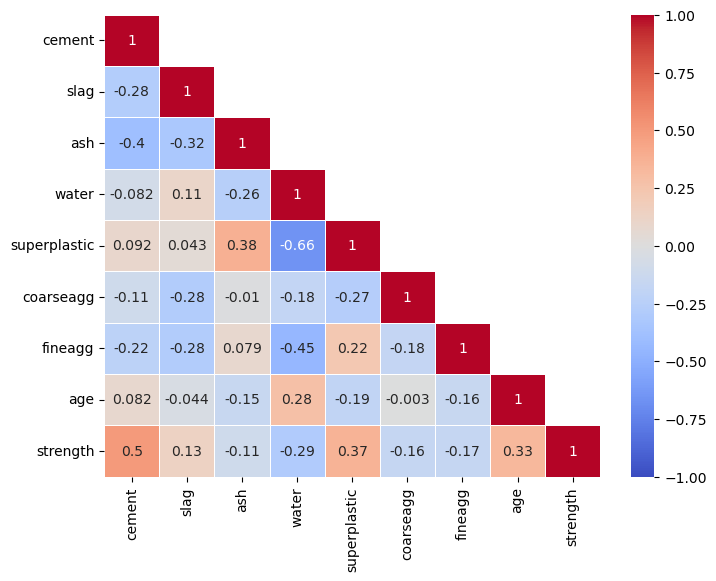

In [2387]:
correlation_matrix = cement_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(8, 6))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.show()

Positive Correlations:

- Cement and Strength (0.5):
  - Cement is positively correlated with compressive strength. As cement content increases, the strength tends to improve.
- Superplasticizer and Strength (0.37):
  - Superplasticizer also has a moderate positive correlation with compressive strength, suggesting that its presence improves strength.
- Age and Strength (0.33):
  - There is a moderate positive correlation between compressive strength and age, implying that concrete becomes stronger as it ages. 
- Water and Age (0.28):
  - Water content has a moderate positive correlation with the age of the concrete.

Negative Correlations:
- Water and Superplasticizer (-0.66):
  - There is a strong negative correlation between water and superplasticizer content.
- Water and Strength (-0.44):
  - Higher water content tends to lower the compressive strength.
- Cement and Ash (-0.4):
  - Cement and ash are moderately negatively correlated.

#### Plotting histograms for all variables in the dataset:

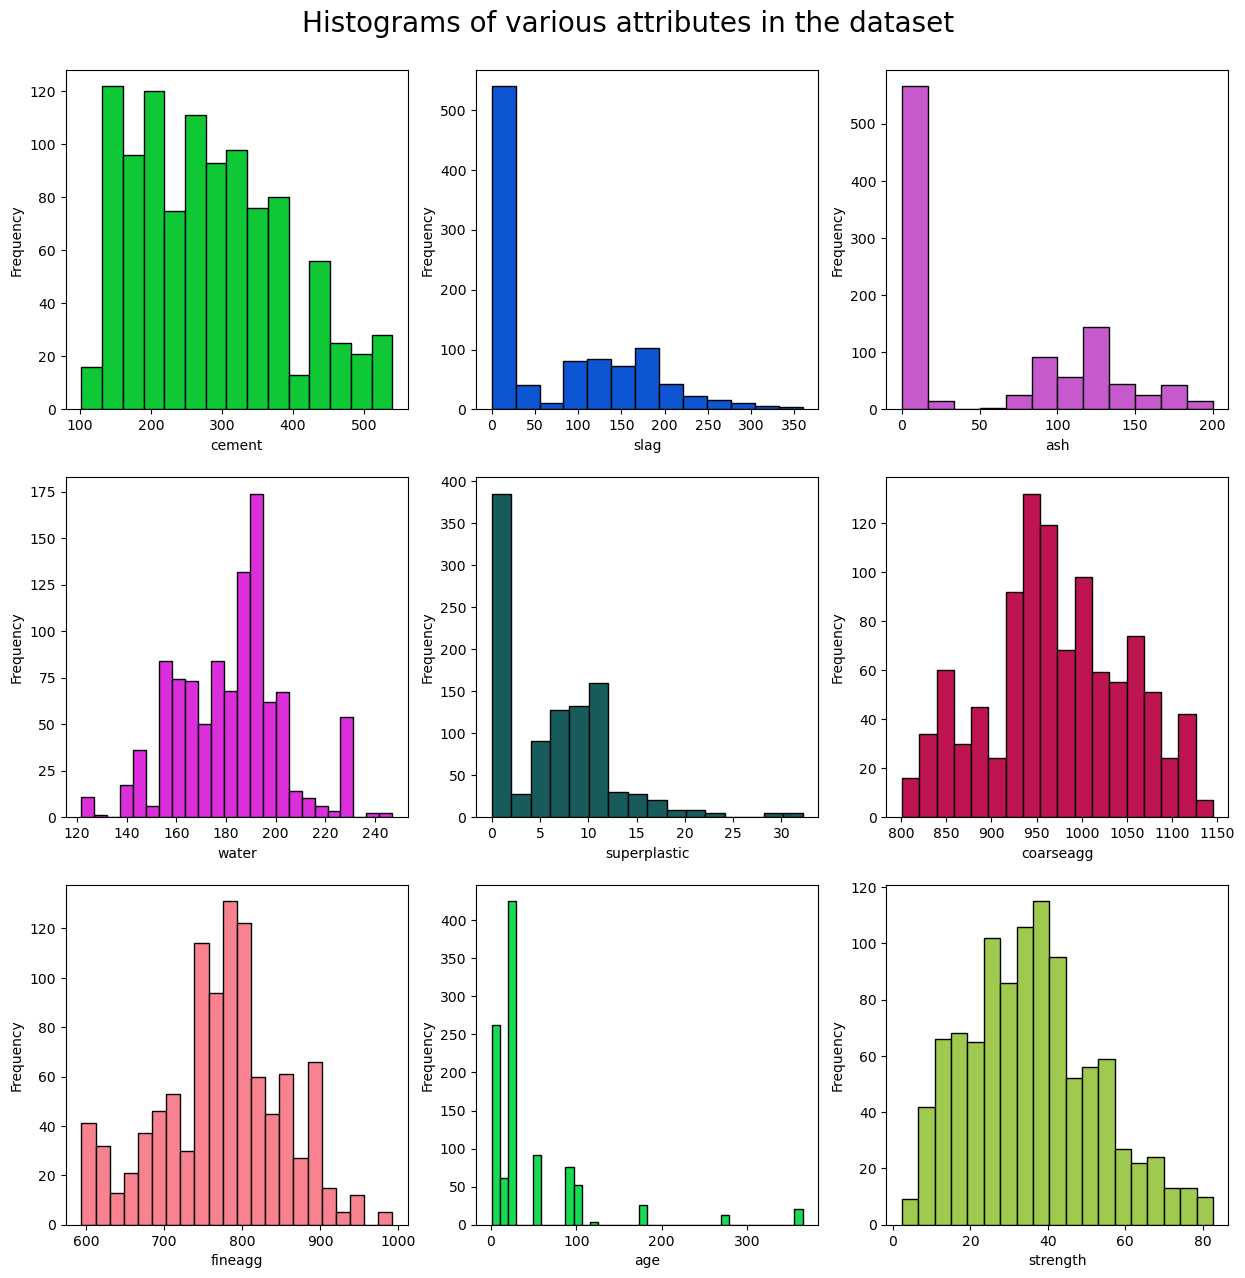

In [2614]:
hist_fig, hist_ax = subplots(3,3,figsize=(15,15))
hist_xlabels = cement_data.columns

for ax, column, xlabel in zip(hist_ax.flatten(), cement_data.columns, hist_xlabels):
    colour = np.random.rand(3)
    ax.hist(cement_data[column], bins = 'auto' , color = colour, edgecolor = 'black')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

hist_fig.suptitle("Histograms of various attributes in the dataset", fontsize = 20, y=0.92);

- For 'water', 'coarseagg', 'fineagg', and 'strength', most of the data is concentrated around the center, resembling a normal distribution.
- For 'slag', 'ash', 'superplastic', and 'age', the distribution is right-skewed, with most data points concentrated towards the lower values.

#### Boxplot of the response 'Strength' grouped by the predictor 'age':

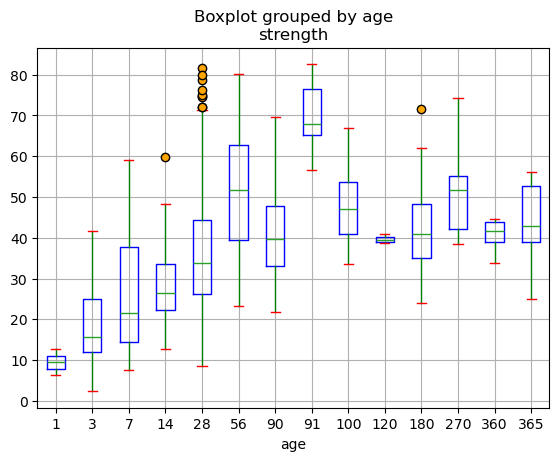

In [2611]:
cement_data.boxplot(column = 'strength',
                    by = 'age',
                    boxprops=dict(color="blue"),
                    whiskerprops=dict(color="green"),
                    capprops=dict(color="red"),     
                    flierprops=dict(markerfacecolor="orange", marker="o", markersize=6));


Based on the boxplot, as age increases, strength rises up to a certain point (until 91 days), after which it begins to decrease.

#### Producing scatter plots of the response 'Strength' against the predictors:

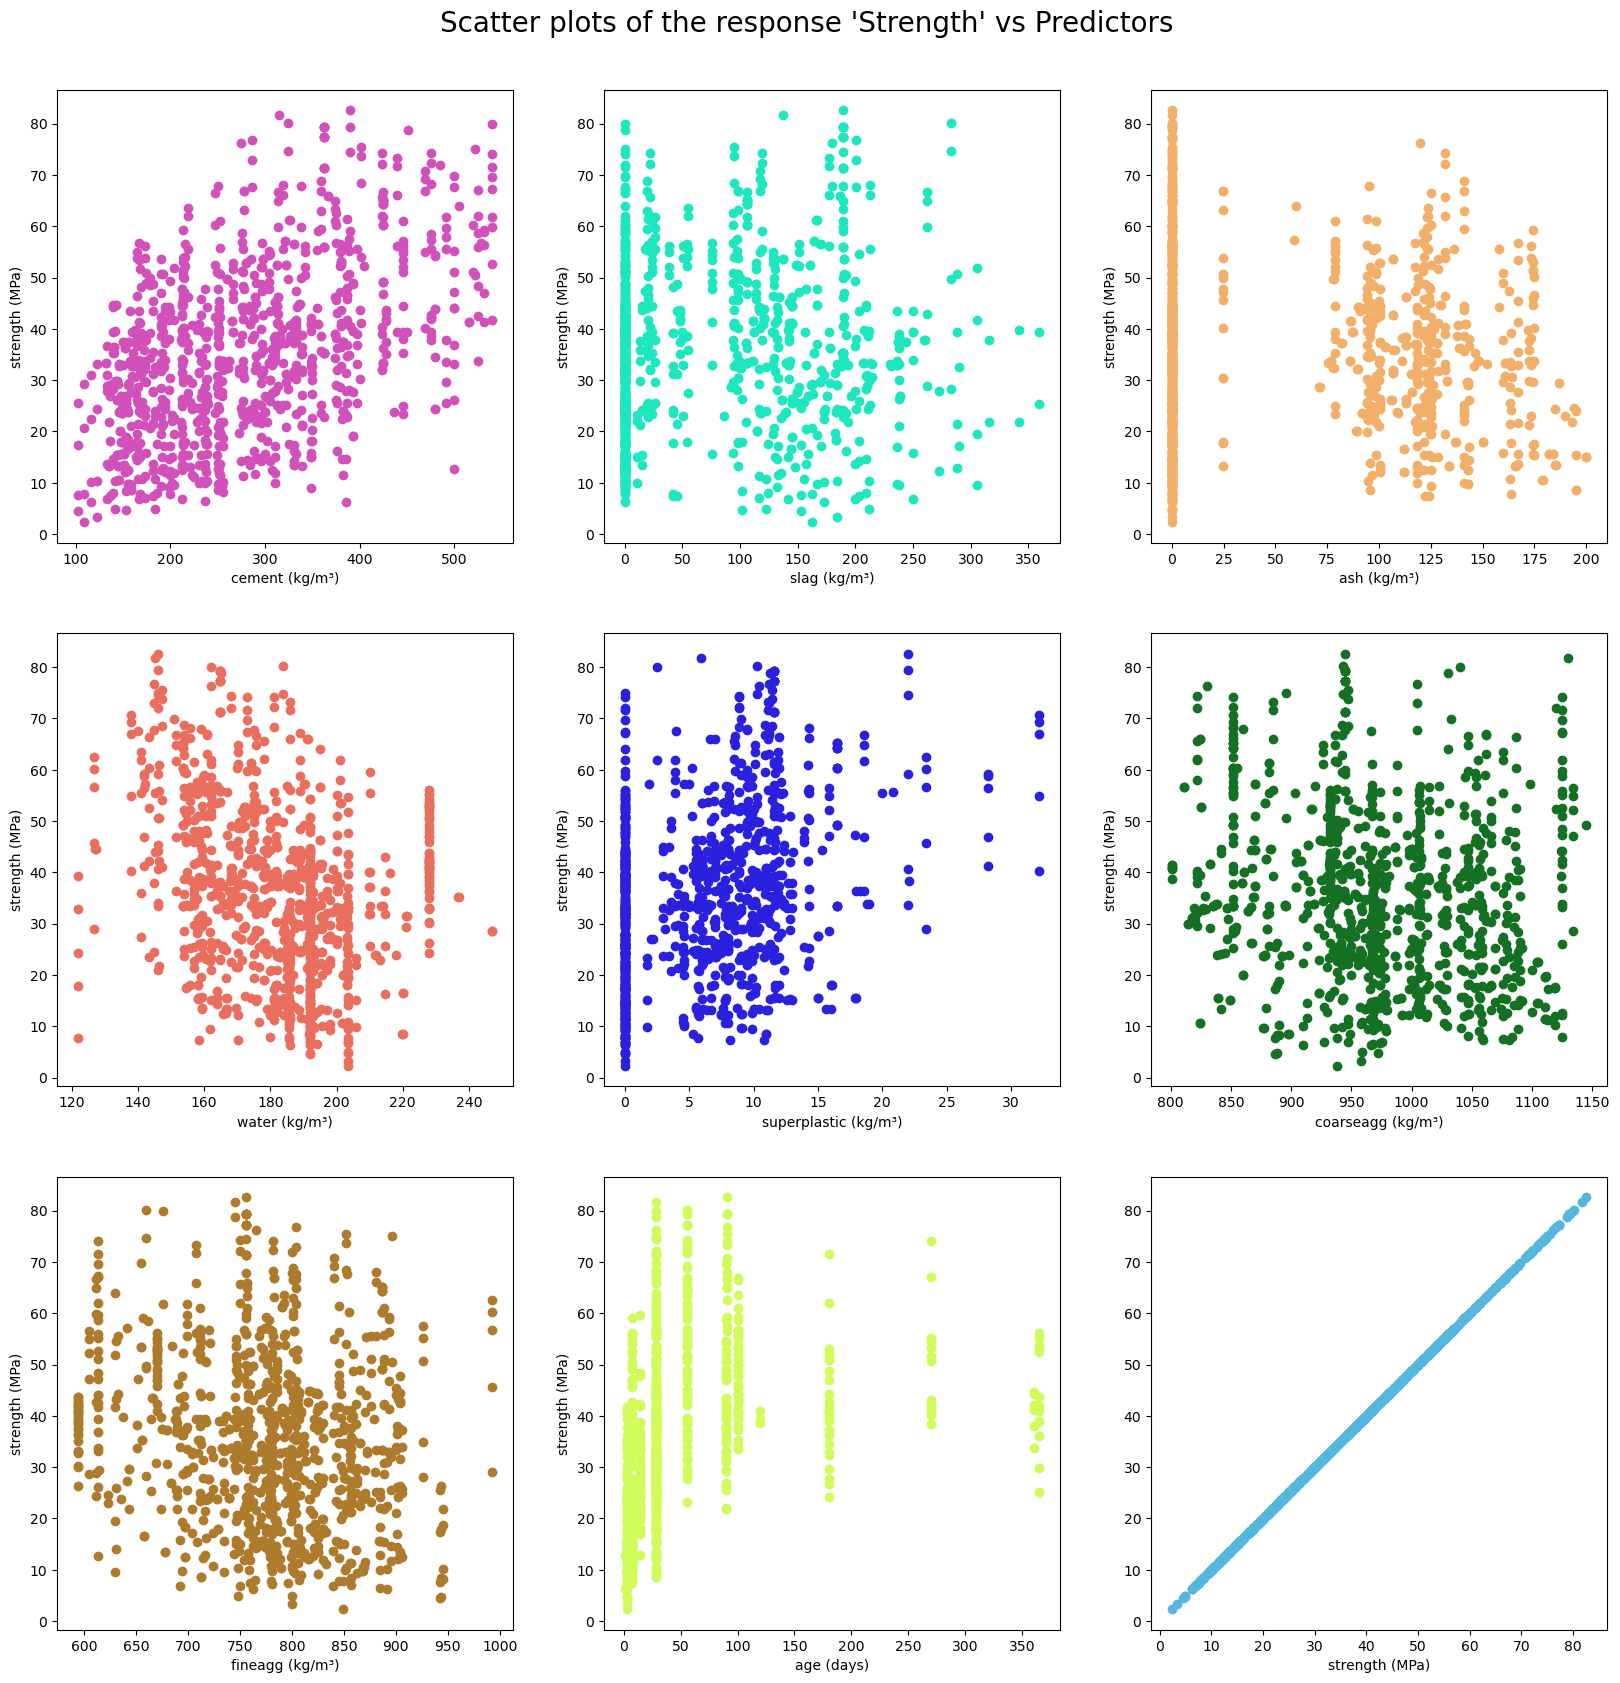

In [2633]:
scatter_fig, scatter_ax = subplots(3,3, figsize=(20,20))

for ax, column, xlabel in zip(scatter_ax.flatten(), cement_data.columns, hist_xlabels):
    colour = np.random.rand(3)
    ax.scatter(cement_data[column], cement_data['strength'], color = colour)
    if column == 'age':
        ax.set_xlabel(column + ' (days)')
    else:
        if column == 'strength':
            ax.set_xlabel(column + ' (MPa)')
            continue
            
        ax.set_xlabel(column + ' (kg/m³)')
        
    ax.set_ylabel('strength (MPa)')

scatter_fig.suptitle("Scatter plots of the response 'Strength' vs Predictors", fontsize = 20, y=0.92);

- As observed from the correlation matrix, 'strength' appears to increase (positively correlated) with 'cement', 'age', and 'superplastic' based on the scatter plots.

- Similarly, 'strength' seems to decrease (negatively correlated) with 'water'.

- 'strength' doesn’t appear to vary significantly with increases in 'slag', 'ash', 'coarseagg', and 'fineagg'.

Additionally, it appears that the existing relationships may be non-linear in nature.

#### Predictive Analysis: Regression

For the purposes of this project, the final model is required to be cross-validated using a portion of the original dataset. 

An 80-20 split will be used to ensure sufficient data for both training and evaluating the model's performance.

In [2641]:
cement_train, cement_test = train_test_split(cement_data,
                                              test_size=0.2,
                                              random_state=54)

print(len(cement_data), len(cement_train), len(cement_test))

X_train, y_train = cement_train[predictors], cement_train[response]
X_test, y_test = cement_test[predictors], cement_test[response]

1030 824 206


#### Multiple Linear Regression 

Performing Multiple Linear Regression with 'strength as 'response'

$$ \hat{Y} = \hat{\beta_0} + \hat{\beta_1} \cdot X_{\text{cement}} + \hat{\beta_2} \cdot X_{\text{slag}} + \hat{\beta_3} \cdot X_{\text{ash}} + \hat{\beta_4} \cdot X_{\text{water}} + \hat{\beta_5} \cdot X_{\text{superplastic}} + \hat{\beta_6} \cdot X_{\text{coarseagg}} + \hat{\beta_7} \cdot X_{\text{fineagg}} + \hat{\beta_8} \cdot X_{\text{age}} $$



In [2659]:
design_mlr = MS(predictors)
X_train_mlr = design_mlr.fit_transform(X_train)  #intercept present in X_train_mlr

results_mlr = sm.OLS(y_train, X_train_mlr).fit()
results_mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               strength   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     171.3
Date:                Mon, 02 Dec 2024   Prob (F-statistic):          7.43e-169
Time:                        00:23:18   Log-Likelihood:                -3074.7
No. Observations:                 824   AIC:                             6167.
Df Residuals:                     815   BIC:                             6210.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -6.9671     29.377     -0.237      0.813     -64.630      50.696
cement           0.1145      0.009     12.148      0.000       0.096       0.133
slag             0.0963      0.011      8.617      0.000       0.074       0.118
ash              0.0793      0.014      5.737      0.000       0.052       0.106
water           -0.1786      0.044     -4.023      0.000      -0.266      -0.091
superplastic     0.3120      0.104      3.012      0.003       0.109       0.515
coarseagg        0.0144      0.010      1.397      0.163      -0.006       0.035
fineagg          0.0138      0.012      1.163      0.245      -0.009       0.037
age              0.1174      0.006     19.222      0.000       0.105       0.129
==============================================================================
Omnibus:                        6.068   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                5.928
Skew:                          -0.196   Prob(JB):                       0.0516
Kurtosis:                       3.137   Cond. No.                     1.07e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The p-values of 'coarseagg' and 'fineagg' are high (greater than 0.05), indicating that they do not contribute to the model's predictive power.

#### Calculating the Training MSE and Test MSE of this model:

In [2908]:
X_test_mlr = design_mlr.fit_transform(X_test)


mlr_train_mse = ((results_mlr.predict(X_train_mlr) - y_train)**2).mean()
mlr_train_mse = round(mlr_train_mse, 4)
mlr_test_mse = ((results_mlr.predict(X_test_mlr) - y_test)**2).mean()
mlr_test_mse = round(mlr_test_mse, 4)

pd.DataFrame([[mlr_train_mse, mlr_test_mse]],columns = ['Training MSE', 'Test MSE'])

,Training MSE,Test MSE
0,102.0094,129.6779


As expected, the test MSE (130) is higher than the training MSE (102).

However, from the scatter plots produced earlier, it was evident that the 'strength' variable is non-linearly correlated with its predictors. Therefore, the linear subset of multiple regression models is not ideal for prediction accuracy. Linear models are highly biased as it cannot capture the non-linear relationships.

To address this bias, some variance needs to be introduced in order to reduce the test MSE. 

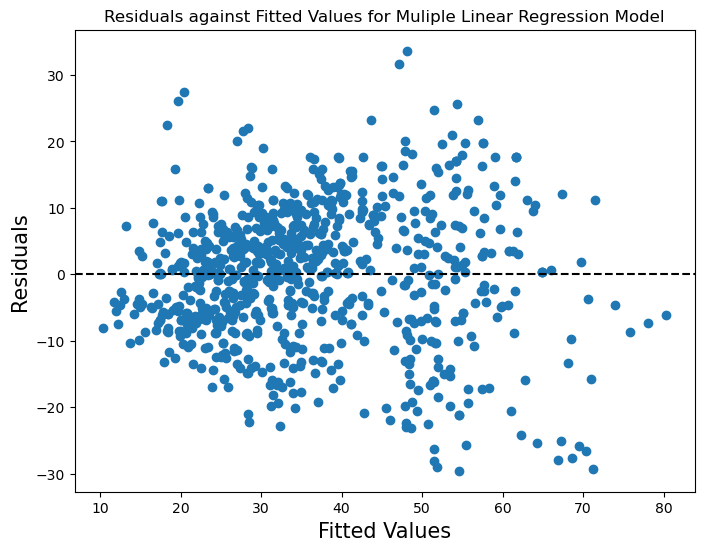

In [3478]:
plt.subplots(figsize=(8,6))
plt.scatter(results_mlr.fittedvalues, results_mlr.resid)
plt.axhline(0, c='k', ls='--');
plt.xlabel('Fitted Values', fontsize=15);
plt.ylabel('Residuals', fontsize=15);
plt.title("Residuals against Fitted Values for Muliple Linear Regression Model");

The residuals are not randomly scattered around the horizontal axis (the zero line), indicating that there might be a non-linear relationships between the features and the response.

#### Polynomial Regression

Polynomial Regression can capture non linear relationships between the response and predictors that the linear multiple regression cannot, therby reducing the bias and improving the test MSE. 

To estimate the optimal polynomial degree for reducing the test MSE, 10-fold cross-validation is performed.

In [2684]:
cv_error = []

cv = KFold(n_splits=10,
           shuffle=True,
           random_state=0)

Y = np.array(y_train)
H = np.array(X_train)

M = sklearn_sm(sm.OLS)

for i in range(1,9+1):
    
    X = H
    if i == 1:
        X = H
    else:
        for j in range(2,i+1):
            X = np.concatenate([X, H**j], axis = 1)
    
    M_CV = cross_validate(M,
                          X,
                          Y,
                          cv=cv)
    
    cv_error.append(np.mean(M_CV['test_score']))
    
cv_error

[104.57548306735183,
 65.05170841233821,
 49.99710076975071,
 41.07224659732246,
 42.684512081833375,
 86.2125354773635,
 116.18926190126555,
 132.40488874054884,
 149.98705815432308]

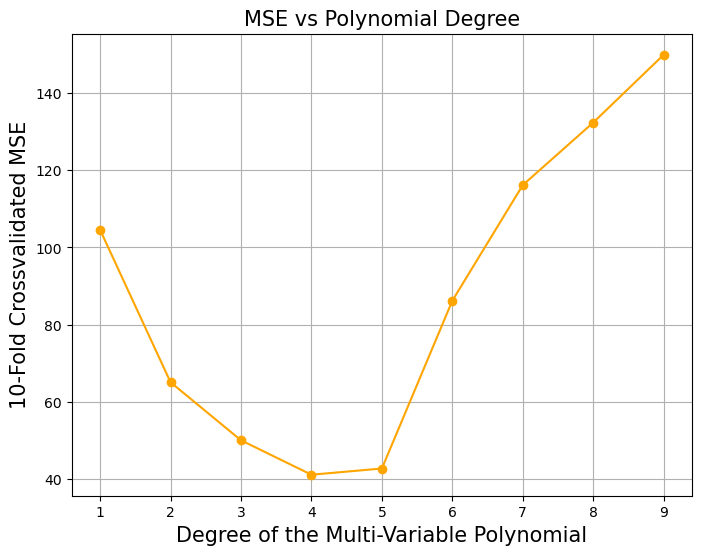

In [2717]:
plt.figure(figsize=(8, 6))
plt.title("MSE vs Polynomial Degree", fontsize = 15)
plt.plot(range(1,len(cv_error)+1), cv_error, color='orange', marker='o');
plt.xlabel('Degree of the Multi-Variable Polynomial', fontsize=15);
plt.ylabel('10-Fold Crossvalidated MSE', fontsize=15);
plt.grid(True)

As expected, the test MSE decreases up to a certain point and then starts increasing due to the higher-order polynomials. The analysis shows that the 4th-degree multivariable polynomial provides the best prediction accuracy.

However, the 4th-degree polynomial is not highly interpretable, as it requires 33 coefficients (1 + 4 × 8). 

Subset selection can be applied to reduce the number of coefficients.

#### Subset Selection

Creating a new input DataFrame to include the 2nd, 3rd, and 4th-order terms of the predictors:

In [2713]:
cement_train_4th_degree = cement_train.copy()

for i in range(2,5):
    for predictor in predictors:
        cement_train_4th_degree[predictor + '^' + str(i)] = cement_train_4th_degree[predictor]**i

cement_train_4th_degree

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,cement^2,...,fineagg^3,age^3,cement^4,slag^4,ash^4,water^4,superplastic^4,coarseagg^4,fineagg^4,age^4
1005,387.0,20.0,94.0,157.0,14.3,938.0,845.0,28,50.24,149769.00,...,6.033511e+08,21952,2.243075e+10,1.600000e+05,7.807490e+07,6.075732e+08,41816.1601,7.741255e+11,5.098317e+11,614656
453,446.0,24.0,79.0,162.0,11.6,967.0,712.0,56,56.14,198916.00,...,3.609441e+08,175616,3.956758e+10,3.317760e+05,3.895008e+07,6.887475e+08,18106.3936,8.743914e+11,2.569922e+11,9834496
494,277.2,97.8,24.5,160.7,11.2,1061.7,782.5,3,30.45,76839.84,...,4.791296e+08,27,5.904361e+09,9.148616e+07,3.603001e+05,6.669043e+08,15735.1936,1.270595e+12,3.749189e+11,81
163,520.0,0.0,0.0,170.0,5.2,855.0,855.0,28,60.28,270400.00,...,6.250264e+08,21952,7.311616e+10,0.000000e+00,0.000000e+00,8.352100e+08,731.1616,5.343976e+11,5.343976e+11,614656
487,162.0,207.0,172.0,216.0,10.0,822.0,638.0,28,39.84,26244.00,...,2.596941e+08,21952,6.887475e+08,1.836037e+09,8.752131e+08,2.176782e+09,10000.0000,4.565489e+11,1.656848e+11,614656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,212.0,141.3,0.0,203.5,0.0,973.4,750.0,3,6.81,44944.00,...,4.218750e+08,27,2.019963e+09,3.986288e+08,0.000000e+00,1.714974e+09,0.0000,8.977706e+11,3.164062e+11,81
708,295.0,0.0,0.0,185.0,0.0,1069.0,769.0,28,25.18,87025.00,...,4.547566e+08,21952,7.573351e+09,0.000000e+00,0.000000e+00,1.171351e+09,0.0000,1.305903e+12,3.497078e+11,614656
617,295.8,0.0,0.0,185.7,0.0,1091.4,769.3,7,14.84,87497.64,...,4.552890e+08,343,7.655837e+09,0.000000e+00,0.000000e+00,1.189180e+09,0.0000,1.418848e+12,3.502539e+11,2401
17,336.0,0.0,0.0,182.0,3.0,986.0,817.0,28,44.86,112896.00,...,5.453385e+08,21952,1.274551e+10,0.000000e+00,0.000000e+00,1.097199e+09,81.0000,9.451651e+11,4.455416e+11,614656


In [1002]:
def adjR2(sigma2, estimator, X, Y):
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    TSS = np.sum((Y - Y.mean())**2)
    R2 = 1 - RSS / TSS
    adj_R2 = 1 - (1-R2**2) * (n-1) / (n-p-1)
    return adj_R2

X_4th_degree = cement_data_4th_degree.drop(columns = ['strength'])

design_4th_order = MS(X_4th_degree.columns)
X_4th_degree = design_4th_order.fit_transform(X_4th_degree)

Y_4th_degree = np.array(cement_data['strength'])

sigma2 = sm.OLS(Y_4th_degree, X_4th_degree).fit().scale

adj_R2 = partial(adjR2, sigma2)

# Stepwise forward
strategy = Stepwise.first_peak(design_4th_order,
                               direction='forward',
                               min_terms = 1,
                               max_terms= 10)#len(design_4th_order.terms))

df_adj_R2 = sklearn_selected(sm.OLS,strategy, scoring=adj_R2)
df_adj_R2.fit(X_4th_degree, Y_4th_degree)
#df_adj_R2.fit(cement_data_4th_degree.drop(columns = ['strength']), Y_4th_degree)

Using Adjusted $ R^2 $ as the scoring metric for both-direction stepwise subset selection to choose the best model, with a range of predictor terms between 1 and 12.

The number 12 is an arbitrary choice, selected with model interpretability in mind. Using the maximum number of terms (33) would result in a model with too many variables, making it less interpretable, which undermines the purpose of regression analysis.

In [3104]:
def adjR2(sigma2, estimator, X, Y):
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    TSS = np.sum((Y - Y.mean())**2)
    R2 = 1 - RSS / TSS
    adj_R2 = 1 - (1-R2**2) * (n-1) / (n-p-1)
    return adj_R2

X_train_4th_degree = cement_train_4th_degree.drop(columns = ['strength'])

design_train_4th_order = MS(X_train_4th_degree.columns)

X_train_4th_degree = design_train_4th_order.fit_transform(X_train_4th_degree)

Y_train_4th_degree = np.array(cement_train_4th_degree['strength'])

sigma2 = sm.OLS(Y_train_4th_degree, X_train_4th_degree).fit().scale

adj_R2 = partial(adjR2, sigma2)

strategy = Stepwise.first_peak(design_train_4th_order,
                               direction = 'both',
                               min_terms = 1,
                               max_terms = 12)

df_adj_R2 = sklearn_selected(sm.OLS,strategy, scoring=adj_R2)
df_adj_R2.fit(X_train_4th_degree, Y_train_4th_degree)


Printing out the predictors chosen by the subset selection model:

In [3107]:
df_adj_R2.selected_state_

('age',
 'age^2',
 'age^3',
 'age^4',
 'ash',
 'cement',
 'slag',
 'superplastic',
 'superplastic^2',
 'water',
 'water^2',
 'water^4')

The best subset selection model, containing 12 variables, includes both linear and non-linear (polynomial) terms for certain predictors. The model consists of the following variables:

1. age (linear term)
2. age$^2$ (quadratic term of age)
3. age$^3$ (cubic term of age)
4. age$^4$ (quartic term of age)
5. ash (linear term)
6. cement (linear term)
7. slag (linear term)
8. superplastic (linear term)
9. superplastic$^2$ (quadratic term of superplastic)
10. water (linear term)
11. water$^2$ (quadratic term of water)
12. water$^4$ (quartic term of water)

This model omits the coarseagg and fineagg variables owing to the fact that they don't add any predictive power to the 12-term quadratic model.

#### Summarizing the Regression Results:

In [3111]:
df_adj_R2.model_.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     350.3
Date:                Mon, 02 Dec 2024   Prob (F-statistic):          5.50e-311
Time:                        15:59:41   Log-Likelihood:                -2730.5
No. Observations:                 824   AIC:                             5487.
Df Residuals:                     811   BIC:                             5548.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept       -252.5663     57.531     -4.390      0.000    -365.493    -139.640
age                0.9488      0.038     25.000      0.000       0.874       1.023
age^2             -0.0093      0.001    -15.737      0.000      -0.010      -0.008
age^3           3.539e-05   2.96e-06     11.957      0.000    2.96e-05    4.12e-05
age^4          -4.469e-08   4.47e-09     -9.991      0.000   -5.35e-08   -3.59e-08
ash                0.0392      0.006      6.200      0.000       0.027       0.052
cement             0.1062      0.003     34.332      0.000       0.100       0.112
slag               0.0785      0.004     21.590      0.000       0.071       0.086
superplastic       0.4584      0.128      3.568      0.000       0.206       0.711
superplastic^2    -0.0258      0.005     -4.865      0.000      -0.036      -0.015
water              4.0762      0.851      4.788      0.000       2.405       5.747
water^2           -0.0188      0.004     -5.362      0.000      -0.026      -0.012
water^4         1.006e-07   1.69e-08      5.935      0.000    6.73e-08    1.34e-07
==============================================================================
Omnibus:                        8.256   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.016   Jarque-Bera (JB):               10.257
Skew:                           0.123   Prob(JB):                      0.00593
Kurtosis:                       3.488   Cond. No.                     6.14e+11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.14e+11. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The p-values for all 12 predictors are essentially zero, indicating that each contributes to the model's predictive power. Additionally, the R², Adjusted R², and F-statistic values have improved compared to the multiple linear regression model.

Although the higher-order terms have very low coefficient values, they cannot be disregarded. This is because the response variable ('strength') is measured in MPa (on the order of millions), while the predictors are measured in kg/m³ and days. Additionally, the higher-order terms are significantly larger in magnitude (e.g., days⁴ = 17,748,900,625), meaning the low coefficient values still have a substantial impact.

#### Adjusting the test dataset inputs to be compatible with the best subset selection model:

In [3115]:
X_test_4th_degree = pd.DataFrame()

for new_param in dict(df_adj_R2.model_.fit().params).keys():
    if new_param == 'intercept':
        continue
    if '^' not in new_param:
        X_test_4th_degree[new_param] = X_test[new_param]
    if '^' in new_param:
        new_param_ = new_param.split('^')
        X_test_4th_degree[new_param] = X_test[new_param_[0]]**(int(new_param_[1]))

X_test_4th_degree = MS(X_test_4th_degree.columns).fit_transform(X_test_4th_degree)

X_test_4th_degree

,intercept,age,age^2,age^3,age^4,ash,cement,slag,superplastic,superplastic^2,water,water^2,water^4
555,1.0,28,784,21952,614656,0.0,181.9,272.8,0.0,0.00,185.7,34484.49,1.189180e+09
469,1.0,28,784,21952,614656,0.0,485.0,0.0,0.0,0.00,146.0,21316.00,4.543719e+08
957,1.0,365,133225,48627125,17748900625,0.0,307.0,0.0,0.0,0.00,193.0,37249.00,1.387488e+09
779,1.0,28,784,21952,614656,107.0,298.0,0.0,13.0,169.00,164.0,26896.00,7.233948e+08
44,1.0,91,8281,753571,68574961,0.0,531.3,0.0,28.2,795.24,141.8,20107.24,4.043011e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,1.0,14,196,2744,38416,167.0,167.0,75.4,7.9,62.41,164.0,26896.00,7.233948e+08
361,1.0,360,129600,46656000,16796160000,0.0,277.0,0.0,0.0,0.00,191.0,36481.00,1.330863e+09
593,1.0,56,3136,175616,9834496,132.0,424.0,22.0,8.9,79.21,168.0,28224.00,7.965942e+08
231,1.0,3,9,27,81,121.9,214.9,53.8,9.6,92.16,155.6,24211.36,5.861900e+08


#### Test MSE of the best subset selection model:

In [3118]:
test_mse_best_subset = np.mean((df_adj_R2.model_.fit().predict(X_test_4th_degree) - y_test)**2)
test_mse_best_subset = round(test_mse_best_subset,4)
print(test_mse_best_subset)

46.7471


The test MSE has been significantly reduced from 129 (linear) to 46 (4th-order polynomial), suggesting that the relationship between the response and predictors is highly non-linear.

However, this model is not highly interpretable, as it includes 12 terms. This tradeoff is necessary to achieve higher prediction accuracy.

#### Plotting the residuals against fitted values

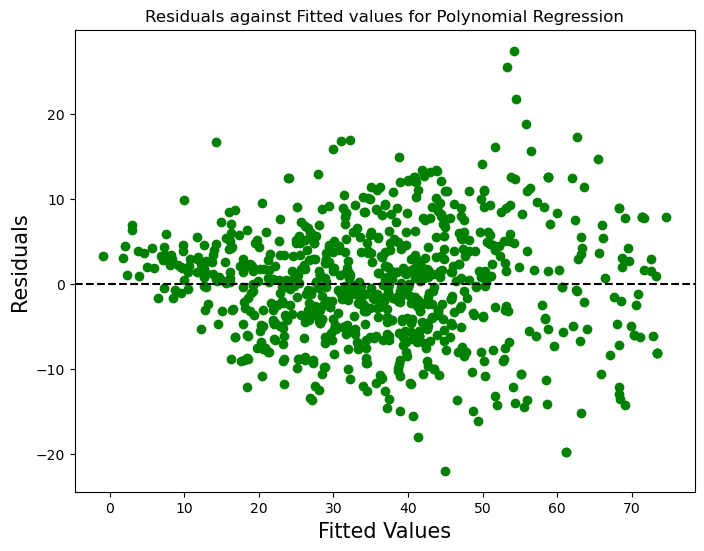

In [3482]:
plt.subplots(figsize = (8,6))
plt.scatter(df_adj_R2.model_.fit().fittedvalues, df_adj_R2.model_.fit().resid, color = 'green')
plt.axhline(0, c='k', ls='--');
plt.xlabel('Fitted Values', fontsize=15);
plt.ylabel('Residuals', fontsize=15);
plt.title('Residuals against Fitted values for Polynomial Regression');

The residuals are more randomly scattered around the horizontal axis (the zero line) compared to the multiple linear regression model.

#### Lasso Regression

Lasso regression is a type of linear regression that applies L1 regularization to shrink some coefficients to zero, performing variable selection. 

It helps improve model simplicity and reduces overfitting by penalizing large coefficients.

In [2804]:
y_lasso = np.array(y_train)
X_lasso = np.array(X_train)

Xs_lasso = X_lasso - X_lasso.mean(0)[None,:]
X_lasso_scale = X_lasso.std(0)
Xs_lasso = Xs_lasso / X_lasso_scale[None,:]
lambdas = 10**np.linspace(6, -2, 100) / y_lasso.std()



array([[ 1.010633  , -0.61737506,  0.62505836, ..., -0.41973501,
         0.91455873, -0.27593146],
       [ 1.58186714, -0.5712189 ,  0.38870308, ..., -0.04664416,
        -0.75814076,  0.17945414],
       [-0.05244342,  0.28036227, -0.47005443, ...,  1.17169043,
         0.12851574, -0.68252575],
       ...,
       [ 0.12764056, -0.84815586, -0.85610138, ...,  1.55378692,
        -0.03749654, -0.61747066],
       [ 0.51685433, -0.84815586, -0.85610138, ...,  0.19779467,
         0.56241147, -0.27593146],
       [-0.47263938, -0.84815586,  0.63451257, ..., -0.30394819,
         1.00511089,  0.89506008]])

In [2808]:
lasso_soln_array = skl.ElasticNet.path(Xs_lasso,
                                       y_lasso,
                                       l1_ratio=1,
                                       alphas=lambdas)[1]

lasso_soln_path = pd.DataFrame(lasso_soln_array.T,
                               columns=cement_data.columns.drop('strength'),
                               index=-np.log(lambdas))

lasso_soln_path.index.name = 'negative log(lambda)'
lasso_soln_path

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
negative log(lambda),,,,,,,,
-11.009741,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000
-10.823673,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000
-10.637606,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000
-10.451538,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000
-10.265471,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000
...,...,...,...,...,...,...,...,...
6.666670,11.789811,8.310679,5.005217,-3.787108,1.816134,1.096443,1.063784,7.214352
6.852737,11.795592,8.316508,5.010174,-3.782773,1.816526,1.100906,1.069264,7.214872
7.038805,11.800391,8.321347,5.014289,-3.779174,1.816851,1.104611,1.073813,7.215304


Plotting the paths to see how the coefficients vary with $\lambda\$ parameter.

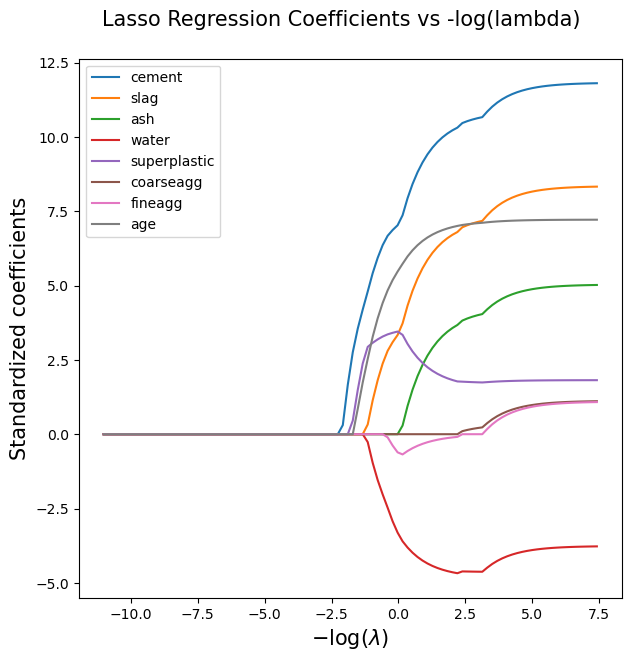

In [2828]:
lasso_path_fig, lasso_path_ax = subplots(figsize=(7,7))
lasso_soln_path.plot(ax=lasso_path_ax, legend=False)
lasso_path_ax.set_xlabel('$-\log(\lambda)$', fontsize=15)
lasso_path_ax.set_ylabel('Standardized coefficients', fontsize=15)
lasso_path_ax.legend(loc='upper left');
lasso_path_fig.suptitle("Lasso Regression Coefficients vs -log(lambda)", fontsize = 15, y = 0.95);

In [2832]:
lasso = skl.ElasticNet(alpha=lambdas[4], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
lasso_pipe = Pipeline(steps=[('scaler', scaler), ('lasso', lasso)])
lasso_pipe.fit(X_lasso, y_lasso)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', ElasticNet(alpha=28723.502011909473, l1_ratio=0))])

Performing 5-Fold Cross Validation to determine the best $\lambda\$ parameter.

In [2834]:
lasso_param_grid = {'lasso__alpha': lambdas}

lasso_kfold = skm.KFold(5, random_state=0, shuffle=True)
lasso_grid = skm.GridSearchCV(lasso_pipe,
                              lasso_param_grid,
                              cv=lasso_kfold,
                              scoring='neg_mean_squared_error')
lasso_grid.fit(X_lasso, y_lasso)
print(lasso_grid.best_params_['lasso__alpha'])
lasso_grid.best_estimator_

0.0018463677111701733


Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', ElasticNet(alpha=0.0018463677111701733, l1_ratio=0))])

The Test MSE (error) is at its lowest when $\lambda\ = 1.846*10^-3$.

Plotting the MSE at each $\lambda\$ value:

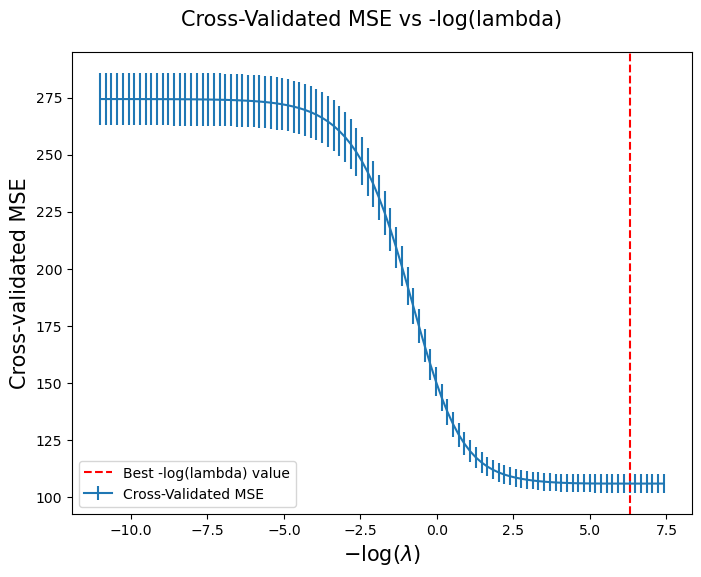

In [3495]:
lasso_cv_fig, lasso_cv_ax = subplots(figsize=(8,6))
lasso_cv_ax.errorbar(-np.log(lambdas),
                    -lasso_grid.cv_results_['mean_test_score'],
                     yerr=lasso_grid.cv_results_['std_test_score'] / np.sqrt(5),
                     label = 'Cross-Validated MSE')

plt.axvline(x=-np.log(0.0018463677111701733), color='red', linestyle='--', label='Best -log(lambda) value')

lasso_cv_ax.set_xlabel('$-\log(\lambda)$', fontsize=15)
lasso_cv_ax.set_ylabel('Cross-validated MSE', fontsize=15);
lasso_cv_ax.legend(loc='lower left');
lasso_cv_fig.suptitle("Cross-Validated MSE vs -log(lambda)", fontsize = 15, y = 0.95);

In [2844]:
for i in range(len(lambdas)): 
    if lambdas[i] == 0.0018463677111701733:
        print(f'The Crossvalidated MSE at the best lambda value: {-lasso_grid.cv_results_['mean_test_score'][i]}')
        break

The Crossvalidated MSE at the best lambda value: 105.83189406225294


When $\lambda\ = 1.846*10^-3$, none of the predictors are close to being zeroed out by the ridge regression model. 

The lowest cross-validated MSE is 106, which is similar to the training MSE of the multiple linear regression model. This is to be expected as lower $\lambda\$ values drive the ridge regresison model to OLS regression while higher values cause it to transform into the null model.

In [2904]:
test_mse_best_lasso = np.mean((lasso_grid.best_estimator_.predict(X_test) - y_test)**2)
test_mse_best_lasso = round(test_mse_best_lasso, 4)
print(test_mse_best_lasso)

129.8918


The Test MSE of the best ridge model is 130, which is exactly the same as the result obtained by the Multiple Linear Regression models.

#### Ridge Regression

Ridge regression introduces a penalty term to the optimization problem in OLS. We penalize 

The predictors have to be scaled before performing ridge regression.

In [2860]:
y_ridge = np.array(y_train)
X_ridge = np.array(X_train)

Xs_ridge = X_ridge - X_ridge.mean(0)[None,:]
X_ridge_scale = X_ridge.std(0)
Xs_ridge = Xs_ridge / X_ridge_scale[None,:]
lambdas = 10**np.linspace(6, -2, 100) / y_ridge.std()


Getting the coefficients of the ridge regression model at each $\lambda\$ value:

In [2863]:
ridge_soln_array = skl.ElasticNet.path(Xs_ridge,
                                       y_ridge,
                                       l1_ratio=0.,
                                       alphas=lambdas)[1]

ridge_soln_path = pd.DataFrame(ridge_soln_array.T,
                               columns=cement_data.columns.drop('strength'),
                               index=-np.log(lambdas))

ridge_soln_path.index.name = 'negative log(lambda)'
ridge_soln_path

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
negative log(lambda),,,,,,,,
-11.009741,0.000137,0.000036,-0.000026,-0.000083,0.000102,-0.000041,-0.000050,0.000090
-10.823673,0.000165,0.000043,-0.000031,-0.000100,0.000123,-0.000049,-0.000061,0.000108
-10.637606,0.000199,0.000052,-0.000038,-0.000120,0.000148,-0.000059,-0.000073,0.000130
-10.451538,0.000240,0.000063,-0.000045,-0.000145,0.000178,-0.000071,-0.000088,0.000157
-10.265471,0.000289,0.000076,-0.000055,-0.000175,0.000215,-0.000086,-0.000106,0.000189
...,...,...,...,...,...,...,...,...
6.666670,11.616159,8.139826,4.854933,-3.895727,1.825608,0.982453,0.915423,7.197776
6.852737,11.650287,8.173539,4.884439,-3.873892,1.824311,1.005397,0.945005,7.201072
7.038805,11.678964,8.201868,4.909227,-3.855480,1.823259,1.024709,0.969892,7.203820


Plotting the paths to see how the coefficients vary with $\lambda\$ parameter.

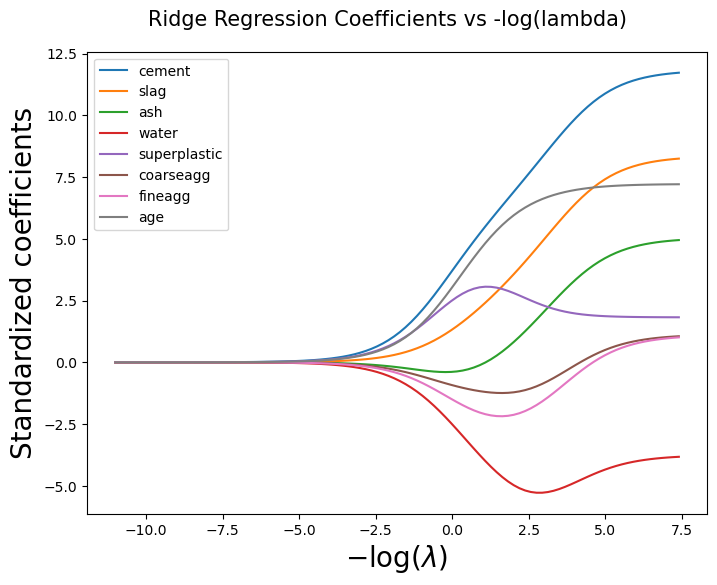

In [3491]:
ridge_path_fig, ridge_path_ax = subplots(figsize=(8,6))
ridge_soln_path.plot(ax=ridge_path_ax, legend=False)
ridge_path_ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ridge_path_ax.set_ylabel('Standardized coefficients', fontsize=20)
ridge_path_ax.legend(loc='upper left');
ridge_path_fig.suptitle("Ridge Regression Coefficients vs -log(lambda)", fontsize = 15, y = 0.95);

In [2868]:
ridge = skl.ElasticNet(alpha=lambdas[4], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
ridge_pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
ridge_pipe.fit(X_ridge, y_ridge)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', ElasticNet(alpha=28723.502011909473, l1_ratio=0))])

Performing 5-Fold Cross Validation to determine the best $\lambda\$ parameter.

In [2871]:
ridge_param_grid = {'ridge__alpha': lambdas}

ridge_kfold = skm.KFold(5, random_state=0, shuffle=True)
ridge_grid = skm.GridSearchCV(ridge_pipe,
                              ridge_param_grid,
                              cv=ridge_kfold,
                              scoring='neg_mean_squared_error')
ridge_grid.fit(X_ridge, y_ridge)
print(ridge_grid.best_params_['ridge__alpha'])
ridge_grid.best_estimator_

0.0018463677111701733


Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', ElasticNet(alpha=0.0018463677111701733, l1_ratio=0))])

The Test MSE (error) is at its lowest when $\lambda\ = 1.846*10^-3$. This is exactly the same $\lambda$ value that was achieved from Lasso Regression.

Plotting the MSE at each $\lambda\$ value:

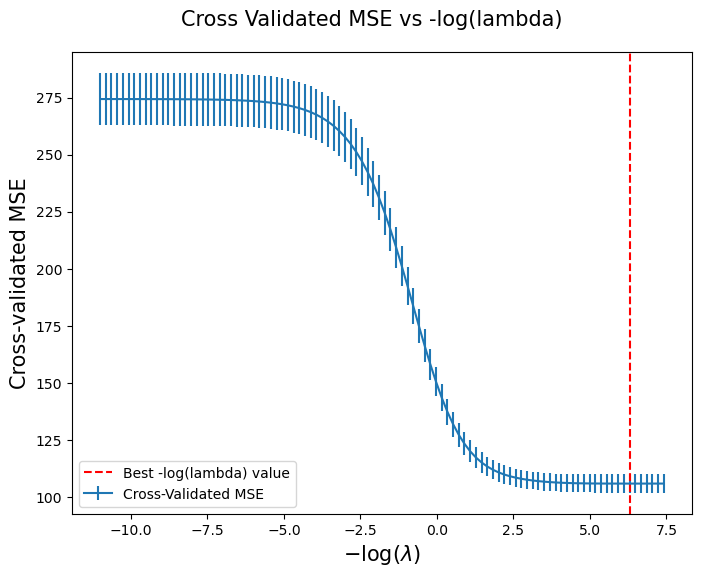

In [3497]:
ridge_cv_fig, ridge_cv_ax = subplots(figsize=(8,6))
ridge_cv_ax.errorbar(-np.log(lambdas),
                    -ridge_grid.cv_results_['mean_test_score'],
                     yerr=ridge_grid.cv_results_['std_test_score'] / np.sqrt(5),
                     label = 'Cross-Validated MSE')

plt.axvline(x=-np.log(0.0018463677111701733), color='red', linestyle='--', label='Best -log(lambda) value')
#ridge_cv_ax.set_ylim([0,10])
ridge_cv_ax.set_xlabel('$-\log(\lambda)$', fontsize=15)
ridge_cv_ax.set_ylabel('Cross-validated MSE', fontsize=15);
ridge_cv_ax.legend(loc='lower left');
ridge_cv_fig.suptitle("Cross Validated MSE vs -log(lambda)", fontsize = 15, y = 0.95);

#### Summary of all the regression models used:

In [2885]:
for i in range(len(lambdas)): 
    if lambdas[i] == 0.0018463677111701733:
        print(f'The Crossvalidated Test MSE at the best lambda value: {-ridge_grid.cv_results_['mean_test_score'][i]}')
        break

The Crossvalidated Test MSE at the best lambda value: 105.83189406225294


When $\lambda\ = 1.846*10^-3$, none of the predictors are close to being zeroed out by the ridge regression model. 

The lowest cross-validated MSE is 106, which is similar to the training MSE of the multiple linear regression model. This is to be expected as lower $\lambda\$ values drive the ridge regresison model to OLS regression while higher values cause it to transform into the null model.

#### Test MSE of the best ridge regression model:

In [2902]:
test_mse_best_ridge = np.mean((ridge_grid.best_estimator_.predict(X_test) - y_test)**2)
test_mse_best_ridge = round(test_mse_best_ridge, 4)
print(test_mse_best_ridge)

129.8918


The Test MSE of the best ridge model is 130, which is exactly the same as the result obtained by the Lasso Regression and the Multiple Linear Regression models. This indicates that all the predictors are important for the prediction accuracy of the linear model, and that the prediction accuracy cannot be reduced beyond a certain point due to the lack of flexibility of the linear model.

In [2923]:
summary_regression = pd.DataFrame([mlr_test_mse, test_mse_best_subset, test_mse_best_lasso, test_mse_best_ridge],columns = ['Test MSE'])
summary_regression.index = ['Multiple Linear Regression', 'Polynomial Regression with subset selection', 'Lasso Regression', 'Ridge Regression']
summary_regression

,Test MSE
Multiple Linear Regression,129.6779
Polynomial Regression with subset selection,46.7471
Lasso Regression,129.8918
Ridge Regression,129.8918


The best-performing model is the Polynomial Regression model with subset selection (47), while multiple linear regression, lasso, and ridge regression yield the same test MSE (130), which is significantly worse.

In terms of interpretability, the MLR model is the most interpretable, followed by the Lasso & Ridge models, and finally the Polynomial subset selection model.

#### Predictive Analysis: Classification

For this part of the project, the real-valued output variable 'strength' has to be converted into a binary variable 'binary_strength'
- binary_strength = class 0, if strength <= 40.0 MPa
- binary_strength = class 1, if strength >  40.0 MPa

in order to perform classification techniques to predict the (binary) variable binary_strength based on the eight attributes.

In [3215]:
cement_data_classification = cement_data.copy()
cement_data_classification['binary_strength'] = (cement_data_classification.strength > 40).astype(int)
cement_data_classification = cement_data_classification.drop(columns = ['strength'])
cement_data_classification.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,binary_strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,0
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,0
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,0
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,1
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,0


#### Printing the Occurrences of each unique value (0 and 1) in the binary_strength column:

In [3217]:
cement_data_classification.binary_strength.value_counts()

binary_strength
0    651
1    379
Name: count, dtype: int64

There are 651 instances of the value 0 (strength <= 40) and 379 instances of the value 1 (strength > 1) in the binary_strength column.

A null model (one that predicts '0' every time) would have an error rate of 37%.

#### Grouping the data by the binary_strength column and calculating the mean and median of each numerical feature for each class (0 and 1):

In [3230]:
cement_data_classification.groupby('binary_strength').mean()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
binary_strength,,,,,,,,
0,247.858986,70.142089,58.618280,185.310445,4.891859,979.794931,781.090783,30.302611
1,338.381794,80.343536,46.579156,175.137731,8.459631,961.108179,760.680211,72.044855


In [3245]:
cement_data_classification.groupby('binary_strength').median()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
binary_strength,,,,,,,,
0,236.0,0.0,0.0,186.0,4.6,974.0,781.0,28.0
1,332.5,76.0,0.0,172.0,8.9,944.7,768.3,56.0


For the purposes of this project, the final model is required to be cross-validated using a portion of the original dataset. 

An 80-20 split will be used to ensure sufficient data for both training and evaluating the model's performance.

In [3148]:
response_binary = 'binary_strength'

In [3150]:
cement_train_cl, cement_test_cl = train_test_split(cement_data_classification,
                                             test_size=0.2,
                                             random_state=99)
X_train_cl, y_train_cl = cement_train_cl[predictors], cement_train_cl[response_binary]
X_test_cl, y_test_cl = cement_test_cl[predictors], cement_test_cl[response_binary]

#### Quadratic Discriminant Analysis (QDA):

The assumption of QDA:

- Normality of the predictors with respect to a response class:
  - As seen from the histograms produced earlier, some of the predictors can be assumed to be normal distributed due to the central tendency of the data.
  - Apart from the plots, if the mean and median are approximately equal, it suggests that the data may be normally distributed:
      - Cement:
        - Response: 0 (Mean ≈ Median)
        - Response: 1 (Mean ≈ Median)
      - Slag:
        - Response: 1 (Mean ≈ Median)
      - Water:
        - Response: 0 (Mean ≈ Median)
        - Response: 1 (Mean ≈ Median)
      - Superplastic:
        - Response: 0 (Mean ≈ Median)
        - Response: 1 (Mean ≈ Median)
      - Fineagg:
        - Response: 0 (Mean ≈ Median)
        - Response: 1 (Mean ≈ Median)
      - Age:
        - Response: 0 (Mean ≈ Median)

In [3178]:
qda = QDA(store_covariance=True)
qda.fit(X_train_cl, y_train_cl)

QuadraticDiscriminantAnalysis(store_covariance=True)

#### Prior Probabilities:

In [3180]:
qda.priors_

array([0.63349515, 0.36650485])

#### Covariance Matrix

In [3182]:
qda.covariance_

[array([[ 7.75228402e+03, -2.85246137e+03, -2.18130302e+03,
          1.18043264e+02, -6.83840032e+01,  1.09174688e+02,
         -1.03963129e+03, -2.95118274e+01],
        [-2.85246137e+03,  8.07304770e+03, -1.49472307e+03,
          3.01248335e+02,  7.59469216e+00, -2.14973871e+03,
         -2.77512690e+03, -3.00707808e+02],
        [-2.18130302e+03, -1.49472307e+03,  4.40260890e+03,
         -4.01725872e+02,  2.10883228e+02, -5.10813222e+02,
         -1.15456692e+02, -4.47770104e+02],
        [ 1.18043264e+02,  3.01248335e+02, -4.01725872e+02,
          3.45589629e+02, -5.11728083e+01, -4.52207398e+02,
         -5.50491886e+02,  2.00873744e+02],
        [-6.83840032e+01,  7.59469216e+00,  2.10883228e+02,
         -5.11728083e+01,  2.72724634e+01, -8.37862264e+01,
          8.29870114e+00, -5.02190174e+01],
        [ 1.09174688e+02, -2.14973871e+03, -5.10813222e+02,
         -4.52207398e+02, -8.37862264e+01,  5.43999734e+03,
         -3.32935119e+02, -1.61105544e+02],
        [-1.0396

#### Confusion Table for the output predicted by QDA for Test Data:

In [3184]:
qda_pred = qda.predict(X_test_cl)
confusion_table(qda_pred, y_test_cl)

Truth,0,1
Predicted,,
0,116,29
1,13,48


#### Prediction Accuracy Rate of QDA model for Test Data:

In [3320]:
accuracy_rate_qda = round(accuracy_score(y_test_cl, qda_pred), 4)
print(accuracy_rate_qda)

0.7961


The accuracy rate of the QDA model for the test data is 79%, but let's see if it can be improved.

#### Performing Subset Selection to improve Test Accuracy:

The below code carries out the forward subset selection algorithm for classification models.

Features (index):
- cement (0)
- slag (1)
- ash (2)
- water (3)
- superplastic (4)
- coarseagg (5)
- fineagg (6)
- age (7)

In [3277]:
def forward_subset_selection_classification(model, X_train_cl, y_train_cl):
    test_error_rates = []
    selected_features = []

    remaining_features = list(range(X_train_cl.shape[1]))
    current_features = []

    while remaining_features:
        error_rates = []
        
        for feature in remaining_features:
            test_features = current_features + [feature]
            
            X_train_cl_subset = X_train_cl.iloc[:, test_features]
            
            model.fit(X_train_cl_subset, y_train_cl)
            
            y_pred = model.predict(X_test_cl.iloc[:, test_features])
            error_rate = 1 - accuracy_score(y_test_cl, y_pred)
            error_rates.append((feature, error_rate))
        
        best_feature, best_error = min(error_rates, key=lambda x: x[1])
        current_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        test_error_rates.append(best_error)
        selected_features.append(current_features)
        
        print(f"Step {len(test_error_rates)}: Selected Feature {best_feature}, Test Error: {best_error}")
    return test_error_rates

In [3279]:
qda_test_error_rates = forward_subset_selection_classification(qda, X_train_cl, y_train_cl)

Step 1: Selected Feature 0, Test Error: 0.31553398058252424
Step 2: Selected Feature 1, Test Error: 0.25728155339805825
Step 3: Selected Feature 2, Test Error: 0.22815533980582525
Step 4: Selected Feature 7, Test Error: 0.2038834951456311
Step 5: Selected Feature 3, Test Error: 0.1893203883495146
Step 6: Selected Feature 5, Test Error: 0.1893203883495146
Step 7: Selected Feature 4, Test Error: 0.19417475728155342
Step 8: Selected Feature 6, Test Error: 0.2038834951456311


#### Plotting the Error Rate against the Number of Predictors

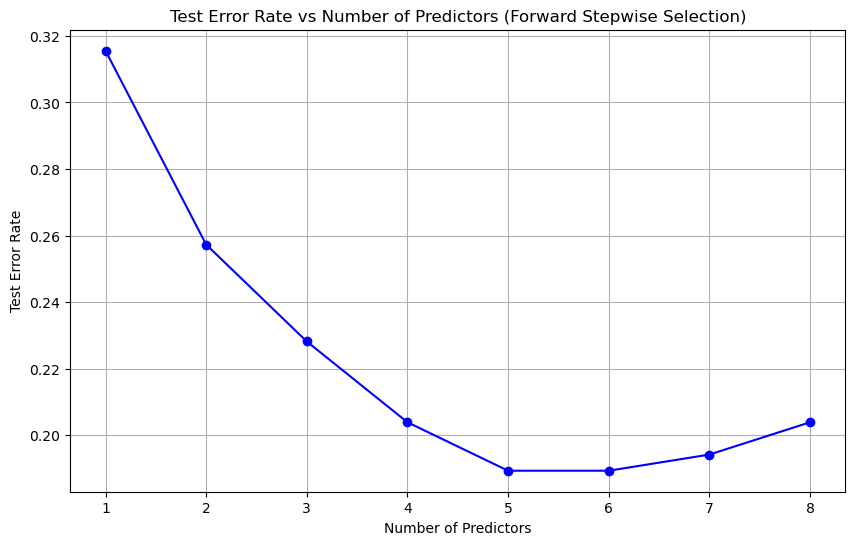

In [3281]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(qda_test_error_rates) + 1), qda_test_error_rates, marker='o', color='b', linestyle='-', label="Test Error Rate")
plt.xlabel('Number of Predictors')
plt.ylabel('Test Error Rate')
plt.title('Test Error Rate vs Number of Predictors (Forward Stepwise Selection)')
plt.grid(True)
plt.show()

The accuracy has improved with 5 predictors, but not by a huge margin. However, it is always useful to remove predictors that do not add any predictive power to a model.

In [1705]:
#Omitted predictors

X_train_cl.iloc[:,[5,4,6]].columns.tolist()

['coarseagg', 'superplastic', 'fineagg']

#### Prediction Accuracy Rate of QDA model for Test Data:

In [3326]:
accuracy_rate_qda_subset = np.mean(QDA().fit(X_train_cl.iloc[:,[0,1,2,3,7]], y_train_cl).predict(X_test_cl.iloc[:,[0,1,2,3,7]]) == y_test_cl)
accuracy_rate_qda_subset = round(accuracy_rate_qda_subset, 4)
print(accuracy_rate_qda_subset)

0.8107


The QDA model with the below predictors yields the best prediction accuracy.

1. cement (0)
2. slag (1)
3. ash (2)
4. water (3)
5. age (7)

While 81% is a decent prediction rate, the QDA model isn't very interpretable as it requires understanding of the full covariance structure for each class.

#### Decision Tree Classifier

Building a Decision Tree Classifier with max_depth = 3

In [3351]:
dtc = DTC(criterion='entropy',
          max_depth = 3,
          random_state=1)

dtc.fit(X_train_cl, y_train_cl)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

In [3353]:
#Training Accuracy

accuracy_score(y_train_cl, dtc.predict(X_train_cl))

0.8216019417475728

#### Prediction Accuracy Rate of Decision Tree for Test Data:

In [3356]:
accuracy_rate_dtc_3 = accuracy_score(y_test_cl, dtc.predict(X_test_cl))
accuracy_rate_dtc_3 = round(accuracy_rate_dtc_3, 4)
accuracy_rate_dtc_3

0.801

#### Plotting the Tree:

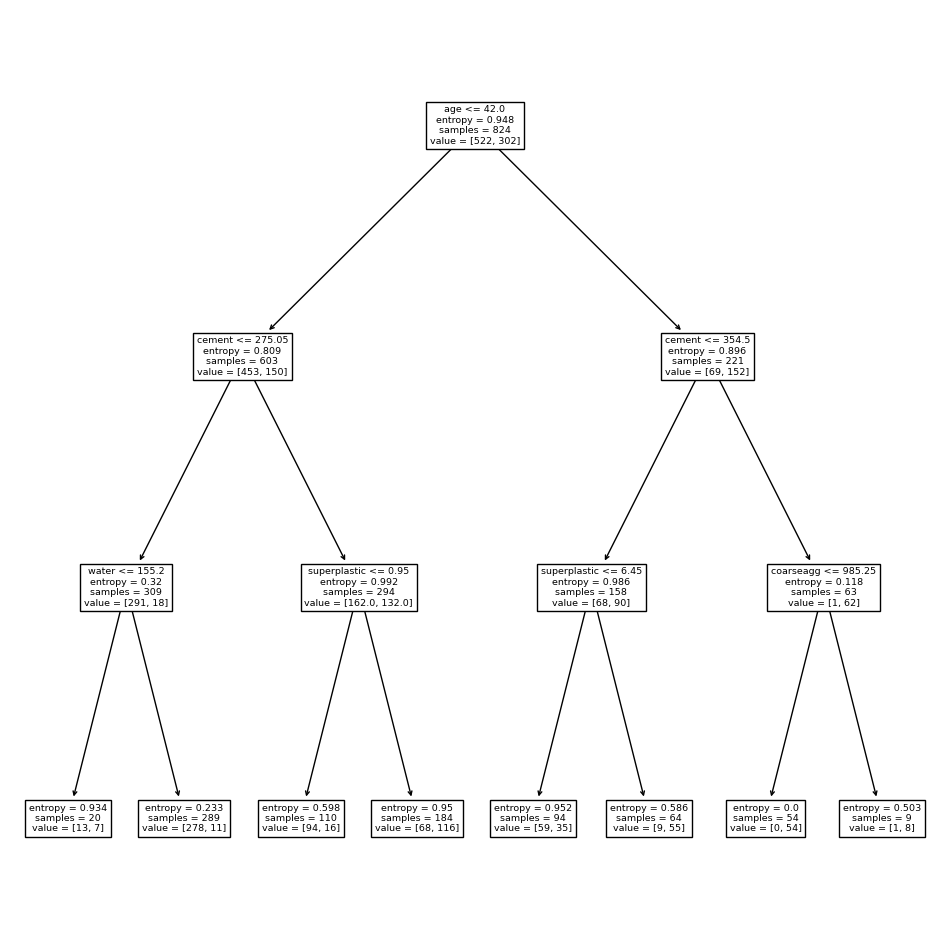

In [3359]:
plot_tree(dtc,
         feature_names=predictors,
         ax=subplots(figsize=(12,12))[1]);

In [3361]:
print(export_text(dtc,
                  feature_names=predictors,
                  show_weights=True))

|--- age <= 42.00
|   |--- cement <= 275.05
|   |   |--- water <= 155.20
|   |   |   |--- weights: [13.00, 7.00] class: 0
|   |   |--- water >  155.20
|   |   |   |--- weights: [278.00, 11.00] class: 0
|   |--- cement >  275.05
|   |   |--- superplastic <= 0.95
|   |   |   |--- weights: [94.00, 16.00] class: 0
|   |   |--- superplastic >  0.95
|   |   |   |--- weights: [68.00, 116.00] class: 1
|--- age >  42.00
|   |--- cement <= 354.50
|   |   |--- superplastic <= 6.45
|   |   |   |--- weights: [59.00, 35.00] class: 0
|   |   |--- superplastic >  6.45
|   |   |   |--- weights: [9.00, 55.00] class: 1
|   |--- cement >  354.50
|   |   |--- coarseagg <= 985.25
|   |   |   |--- weights: [0.00, 54.00] class: 1
|   |   |--- coarseagg >  985.25
|   |   |   |--- weights: [1.00, 8.00] class: 1



#### Improving the Prediction Accuracy of the Tree by pruning branches using 10-Fold Cross Validation:

In [3363]:
dtc = DTC(criterion='entropy',
          random_state=0)

ccp_path = dtc.cost_complexity_pruning_path(X_train_cl, y_train_cl)

kfold = skm.KFold(10,
                  random_state=1,
                  shuffle=True)

grid = skm.GridSearchCV(dtc,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')

grid.fit(X_train_cl, y_train_cl)
grid.best_score_

0.8786400591278639

#### Prediction Accuracy of the Pruned Tree:

In [3364]:
accuracy_score(grid.best_estimator_.predict(X_test_cl), y_test_cl)

0.912621359223301

#### Confusion Table:

In [2152]:
confusion_table(y_test_cl, grid.best_estimator_.predict(X_test_cl))

Truth,0,1
Predicted,,
0,122,7
1,11,66


In [2146]:
grid.best_estimator_.tree_.n_leaves

84

The best tree has 84 terminal nodes.

#### Plotting the best tree:

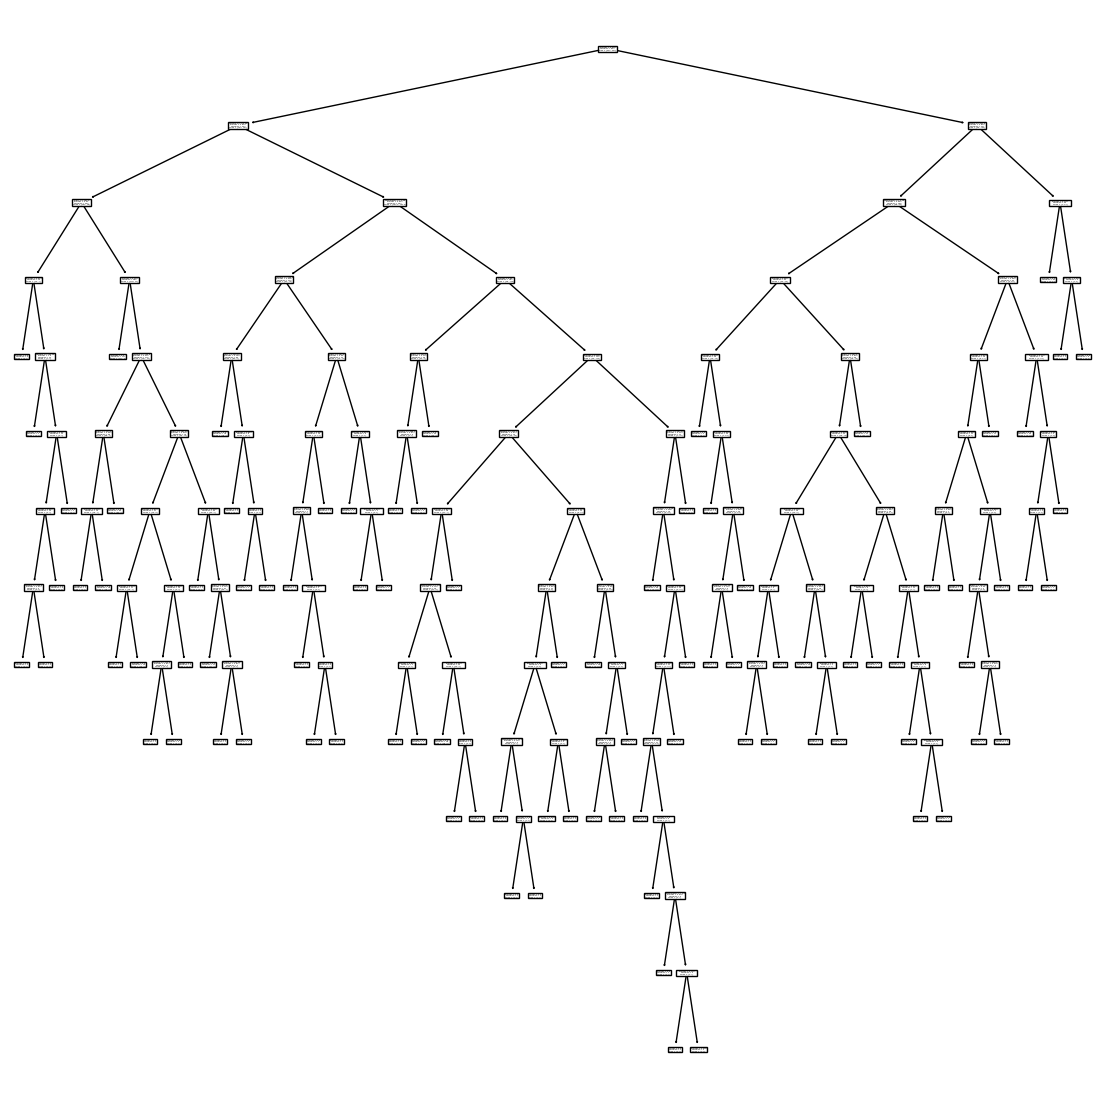

In [3377]:
plot_tree(grid.best_estimator_,
         feature_names=predictors,
         ax=subplots(figsize=(14,14))[1]);

In [2154]:
print(export_text(grid.best_estimator_,
                  feature_names=predictors,
                  show_weights=True))

|--- age <= 42.00
|   |--- cement <= 275.05
|   |   |--- water <= 155.20
|   |   |   |--- age <= 8.50
|   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |--- age >  8.50
|   |   |   |   |--- cement <= 190.75
|   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |   |   |--- cement >  190.75
|   |   |   |   |   |--- fineagg <= 894.40
|   |   |   |   |   |   |--- age <= 21.00
|   |   |   |   |   |   |   |--- cement <= 232.50
|   |   |   |   |   |   |   |   |--- weights: [3.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- cement >  232.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |--- age >  21.00
|   |   |   |   |   |   |   |--- weights: [0.00, 5.00] class: 1
|   |   |   |   |   |--- fineagg >  894.40
|   |   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |--- water >  155.20
|   |   |   |--- age <= 21.00
|   |   |   |   |--- weights: [111.00, 0.00] class: 0
|   |   |   |--- age >  21.00
|   |   |   

In [3384]:
accuracy_rate_dtc_pruned = accuracy_score(DTC(criterion='entropy', random_state=0).fit(X_train_cl, y_train_cl).predict(X_test_cl), y_test_cl)
accuracy_rate_dtc_pruned = round(accuracy_rate_dtc_pruned, 4)
print(accuracy_rate_dtc_pruned)

0.9126


This tree isn't very interpretable as it has 84 terminal nodes, but it achieves an impressive prediction accuracy of 91%.

#### Logistic Regression

Logistic Regression can be used as the response is binary. It predicts the probability of an outcome based on input features.

$$
P(Y|X) = \frac{e^z}{1 + e^z}
$$

where, $$ z = \hat{\beta_0} + \hat{\beta_1} \cdot X_{\text{cement}} + \hat{\beta_2} \cdot X_{\text{slag}} + \hat{\beta_3} \cdot X_{\text{ash}} + \hat{\beta_4} \cdot X_{\text{water}} + \hat{\beta_5} \cdot X_{\text{superplastic}} + \hat{\beta_6} \cdot X_{\text{coarseagg}} + \hat{\beta_7} \cdot X_{\text{fineagg}} + \hat{\beta_8} \cdot X_{\text{age}} $$


In [1925]:
design_LR = MS(X_train_cl)
X_train_cl_LR = design_LR.fit_transform(X_train_cl)
glm = sm.GLM(y_train_cl,
             X_train_cl_LR,
             family=sm.families.Binomial())
results_glm = glm.fit()
results_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               strength   No. Observations:                  824
Model:                            GLM   Df Residuals:                      815
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -344.09
Date:                Sun, 01 Dec 2024   Deviance:                       688.17
Time:                        15:40:27   Pearson chi2:                 1.20e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3806
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -2.7017      7.369     -0.367      0.714     -17.145      11.742
cement           0.0148      0.002      6.074      0.000       0.010       0.020
slag             0.0089      0.003      3.047      0.002       0.003       0.015
ash              0.0091      0.004      2.459      0.014       0.002       0.016
water           -0.0299      0.011     -2.665      0.008      -0.052      -0.008
superplastic     0.0649      0.029      2.204      0.028       0.007       0.123
coarseagg        0.0014      0.003      0.543      0.587      -0.004       0.007
fineagg         -0.0010      0.003     -0.325      0.746      -0.007       0.005
age              0.0217      0.002      8.990      0.000       0.017       0.026
================================================================================
"""

The negative coefficients of 'water' and 'fineagg' indicate that the probability of binary_strength = 1 decreases as these variables increase. This aligns with the observation that 'strength' is negatively correlated with 'water' and 'fineagg'.

However, the p-values of 'coarseagg' and 'fineagg' are high (greater that 0.05).

#### Confusion Table of the Logistic Regression model

In [3400]:
X_test_cl_LR = design_LR.fit_transform(X_test_cl)

glm_test_prob = results_glm.predict(X_test_cl_LR)
glm_test_result = (glm_test_prob > 0.5).astype(int)

confusion_table(glm_test_result, y_test_cl)

Truth,0,1
Predicted,,
0,120,25
1,9,52


#### Prediction Accuracy of the Logistic Regression Model

In [3403]:
accuracy_rate_lr = accuracy_score(glm_test_result, y_test_cl)
accuracy_rate_lr = round(accuracy_rate_lr, 4)
print(accuracy_rate_lr)

0.835


The prediction accuracy of the fitted logistic model is 83.5%.

Additionally, since 'coarseagg' and 'fineagg' have high p-values (greater than 0.05), subset selection can be explored to determine to improve test accuracy.

#### Performing Subset Selection to improve Test Accuracy:

In [3412]:
test_error_rates = []
selected_features = []

remaining_features = list(range(X_train_cl.shape[1]))
current_features = []

while remaining_features:
    error_rates = []
    
    for feature in remaining_features:
        test_features = current_features + [feature]
        
        X_train_cl_subset = X_train_cl.iloc[:, test_features]
        X_train_cl_subset = MS(X_train_cl_subset.columns).fit_transform(X_train_cl_subset)
        
        glm = sm.GLM(y_train_cl,
                     X_train_cl_subset,
                     family=sm.families.Binomial())
        results_ = glm.fit()

        X_test_cl_subset = X_test_cl.iloc[:, test_features]
        X_test_cl_subset = MS(X_test_cl_subset.columns).fit_transform(X_test_cl_subset)

        y_pred_prob = results_.predict(X_test_cl_subset)
        y_pred = (y_pred_prob > 0.5).astype(int)
        error_rate = 1 - accuracy_score(y_test_cl, y_pred)
        error_rates.append((feature, error_rate))
    
    best_feature, best_error = min(error_rates, key=lambda x: x[1])
    current_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    test_error_rates.append(best_error)
    selected_features.append(current_features)
    
    print(f"Step {len(test_error_rates)}: Selected Feature {best_feature}, Test Error: {best_error}")

Step 1: Selected Feature 7, Test Error: 0.2961165048543689
Step 2: Selected Feature 3, Test Error: 0.22815533980582525
Step 3: Selected Feature 6, Test Error: 0.2038834951456311
Step 4: Selected Feature 5, Test Error: 0.19417475728155342
Step 5: Selected Feature 2, Test Error: 0.1747572815533981
Step 6: Selected Feature 1, Test Error: 0.18446601941747576
Step 7: Selected Feature 0, Test Error: 0.1747572815533981
Step 8: Selected Feature 4, Test Error: 0.16504854368932043


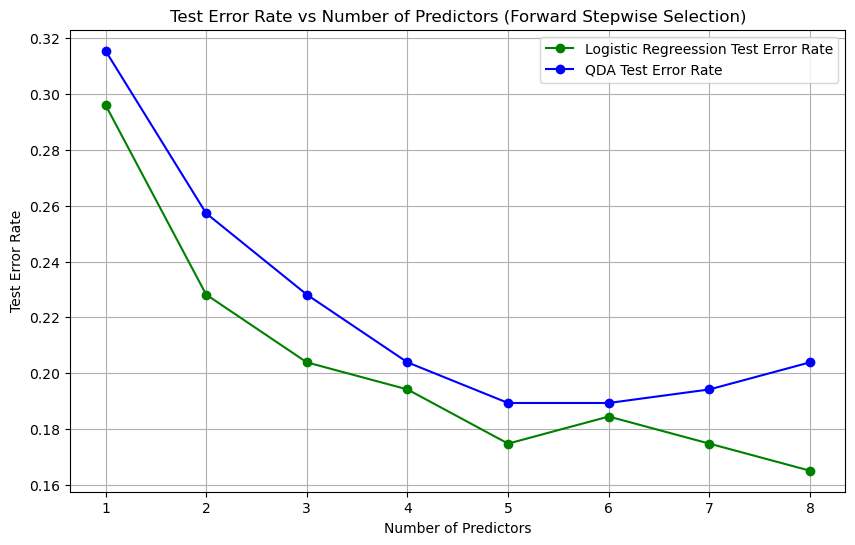

In [3416]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_error_rates) + 1), test_error_rates, marker='o', color='g', linestyle='-', label="Logistic Regreession Test Error Rate")
plt.plot(range(1, len(qda_test_error_rates) + 1), qda_test_error_rates, marker='o', color='b', linestyle='-', label="QDA Test Error Rate")
plt.xlabel('Number of Predictors')
plt.ylabel('Test Error Rate')
plt.title('Test Error Rate vs Number of Predictors (Forward Stepwise Selection)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

The test error rate did not improve with fewer predictors, indicating that 83.5% is the best accuracy achievable by the logistic regression model.

Logistic regression is highly interpretable as it is a parametric model, with the signs of the coefficients providing insight into how the probability of the response changes.

In [3427]:
summary_classification = pd.DataFrame([accuracy_rate_qda_subset, accuracy_rate_dtc_pruned, accuracy_rate_lr],columns = ['Prediction Accuracy'])
summary_classification.index = ['QDA (Subset Selected)', 'Decision Tree Classifier (Pruned)', 'Logistic Regression (Subset Selected)']
summary_classification

,Prediction Accuracy
QDA (Subset Selected),0.8107
Decision Tree Classifier (Pruned),0.9126
Logistic Regression (Subset Selected),0.8350


The best-performing model is the Pruned Decision Tree Classifier.

In terms of interpretability, the Logisitic Regression model is the most interpretable.

#### X-Factor: KNN Regression

KNN (K-Nearest Neighbors) Regression is a non-parametric algorithm that predicts the value of a target variable by averaging the target values of the K nearest neighbors in the feature space.

How it works:

- Training Phase:
  - KNN does not explicitly build a model during the training phase. Instead, it simply stores the training dataset.


- Prediction Phase:
  - For a given test point, the algorithm calculates the distance (e.g., Euclidean, Manhattan) between the test point and all points in the training dataset.
  - It then identifies the K nearest training points (neighbors) to the test point, based on the calculated distance.

 
- Output Calculation:
  - The predicted value for the test point is the average of the target values (for regression) of the K nearest neighbors.
  - The value of K is a user-defined parameter, and it controls how many neighbors are considered. A smaller K may lead to a model that is more sensitive to noise, while a larger K provides smoother predictions but may ignore important local patterns.


- Choosing K:
  - Cross-validation is often used to determine the optimal value of K.

In [3439]:
#10-Nearest Neighbour Regression

knn = KNeighborsRegressor(n_neighbors = 10)

scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.fit_transform(X_test)

knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=10)

#### Training MSE:

In [3441]:
np.mean((knn.predict(X_train_scaled) - y_train)**2)

66.7142400788835

#### Test MSE:

In [3020]:
np.mean((knn.predict(X_test_scaled) - y_test)**2)

92.0068441262136

K = 10 Nearest Neighbours yields a test MSE of 92, which is worse than the result that was achieved earlier through polynomial fits of the predictors.

We can improve this by choosing the ideal K parameter to reduce the MSE through Cross-Validation.

#### Finding the optimal value of K through Cross-Validation:

In [3447]:
knn_k_mse = []
knn_k_test_mse = []
for K in range(1, 16):
    knn = KNeighborsRegressor(n_neighbors = K)
    knn.fit(X_train_scaled, y_train)
    knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    knn_k_mse.append(-knn_cv_scores.mean())

knn_k_mse

[97.99243390096082,
 83.72330809682187,
 80.53415909723249,
 80.70967796618625,
 82.89386452996305,
 83.97912631551284,
 84.94778462247162,
 86.83507300182465,
 91.20183117463708,
 93.02002551085737,
 95.31506101073832,
 97.43903926369384,
 100.35340306958021,
 102.072858626416,
 103.09929942704771]

#### Plotting Cross Validated MSE against K values:

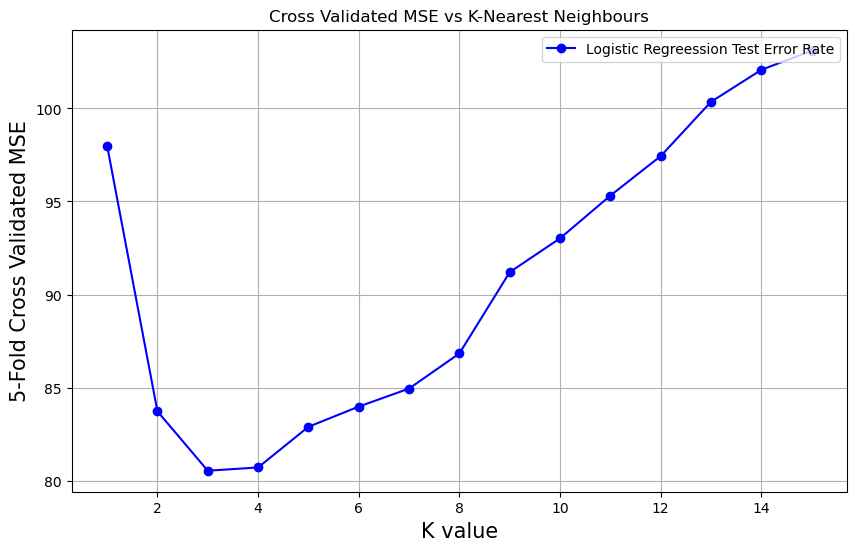

In [3452]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(knn_k_mse) + 1), knn_k_mse, marker='o', color='blue', linestyle='-', label="Logistic Regreession Test Error Rate");
plt.xlabel('K value', fontsize = 15)
plt.ylabel('5-Fold Cross Validated MSE', fontsize = 15)
plt.title('Cross Validated MSE vs K-Nearest Neighbours')
plt.legend(loc='upper right')
plt.grid(True)

The lowest Cross-Validated MSE is at K = 3 based on the 5-fold cross-validation.

In [3064]:
#3-Nearest Neighbour Regression

knn_3 = KNeighborsRegressor(n_neighbors = 3)

scaler_knn_3 = StandardScaler()

knn_3.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=3)

#### Test MSE of 3-Nearest Neighbours Model:

In [3459]:
test_mse_best_knn_regression = np.mean((knn_3.predict(X_test_scaled) - y_test)**2)
test_mse_best_knn_regression = round(test_mse_best_knn_regression, 4)
print(test_mse_best_knn_regression)

71.2839


The 3-Nearest Neighbors model yields a test MSE of 72, outperforming the K = 10 model.

Its prediction accuracy surpasses that of the Linear, Lasso, and Ridge Regression models but falls short of the Polynomial Regression model.

In [3461]:
summary_regression.loc['3-Neighbour KNN Regression'] = [test_mse_best_knn_regression]
summary_regression

,Test MSE
Multiple Linear Regression,129.6779
Polynomial Regression with subset selection,46.7471
Lasso Regression,129.8918
Ridge Regression,129.8918
3-Neighbour KNN Regression,71.2839


#### Extensions

#### Q1:

To optimize the recipe/process for making the strongest possible concrete under budget constraints, optimization techniques such as Linear and Non-Linear Programming can be used. The OLS regression model provides a mathematical equation that returns the compressive strength as a function of the attributes such as cement, water, superplasticizer, aggregates, slag, fly ash, and curing time. 
    
Using this model, the objective would be to maximize Concerete strength by varying input variables within feasible ranges while adhering to budget constraints. The regression function would be our objective function, and the amount of material of each attribute would constitute the decision variables. The constraints would include the total budget, material mix limits, and any additional operational requirements such as labor time and inventory etc. As this project deals with Polynomial Regression, the objective function would be the 4th degree Polynomial that predicts strength based on the attributes.

Non linear Programs can be solved using non-linear optimization techniques such as Steepest Descent, Gradient Descent etc. through softwares like Gurobi and SciPy. LP solvers like Simplex can be used for Linear Programs through softwares like AMPL.

The uncertainity of the regression model can be accounted for by estimating the confidence interval for each prediction that the regression model makes.  

Additionally, industrial engineering techniques such as sensitivity and cost benefit analysis can be performed. For example, we can see if adding 1 kg of superplasticizer is worth the cost for the increase in the strength. We can fine tune the amount of material at our disposal to maximize the output while minimizing the cost through sensitivity and cost benefit analysis.

#### Q2:

To ensure that a proposed combination of input variables produces the Concrete strength requirement of 40.0 MPa, the polynomial regression model predicting strength can be used. Using the regression equation, the proposed input combination would be input into the model to predict the expected strength of the mix. The uncertainty of the model’s prediction, represented by confidence intervals or prediction errors, would be critical in the decision-making process. As this is a maximization problem, looking at lower bound of the confidence interval would be prudent. For example, if the model predicts a strength of 40.5 MPa with a 95% confidence interval of [38.0, 43.0] MPa, the lower bound (38.0 MPa) suggests a risk that the mix might fail to meet the design requirement. 

#### Limitations of the Study:

1. While the Polynomial Regression approach reduced the test MSE significantly, it is not without its disadvantages. For example, the 4th order polynomial is more complex and requires 33 parameters. This makes the model harder to interpret and more computationally expensive. <br> 

2. Polynomial regression models can behave erratically when making predictions outside the range of the given data, especially for high-degree polynomials. The curve can drastically deviate, leading to unrealistic predictions. For example, the 4th order polynomial goes to infinity on both ends (depending on signs) for large input values. <br>

3. Higher-degree polynomials can introduce multicollinearity. Additionally, it cannot capture relationships between predictors that aren't expressed as a natural number power of the features. This means it struggles with interactions or relationships that involve multiplication or other non-polynomial transformations of predictors. For example, it cannot capture non-polynomial relationships like logarithmic and exponential relationships. <br>

4. QDA classification assumes that the features within each class follow normal distribution, but clearly that isn't the case as was observed in the QDA section of this project. <br>
5. The Pruned Decision Tree Classifier implemented in this project has the best predictive accuracy, but it has too many branches and it is less interpretable as a result. <br>

6. With additional time, error modeling techniques could be implemented to enhance prediction accuracy. Additionally, deep learning techniques, such as neural networks, could also be explored. <br>

#### Conclusion:

In conclusion, this project involved the application of various regression and classification techniques to predict the compressive strength of concrete and to assess whether a given mix of predictors such as cement, water, superplasticizer, aggregates, slag, fly ash, and curing time meets a strength requirement of 40 MPa. 

The regression models such as Multiple Linear Regression, 4th Degree Polynomial Regression, Lasso, Ridge, and KNN Regression provided valuable insights into the relationship between concrete mix variables and compressive strength. The 4th Degree Polynomial Regression, in particular, with subset selection achieved the lowest test mean squared error (MSE) of 46.7471, revealing a highly non-linear relationship between strength, curing time (age), and superplasticizer content. The analysis showed that cement content and superplasticizer content positively influence strength, while strength increases with age but up to a certain point, after which it begins to decrease. The Lasso and Ridge regression models did not trim any predictors, suggesting that all predictors added to predictive power of the Multiple Linear Regression Model.

Then, the strength variable was transformed into a binary classification problem. Classification models such as Quadratic Discriminant Analysis (QDA) Decision Tree Classifier, and Logistic Regression models were implemented. Among the classifiers, the Decision Tree Classifier (Pruned) provided the best prediction accuracy of 91.26%, but the Logistic Regression and the QDA models were more interpretable.

One direction for further study could be to explore deep learning techniques, such as neural networks, to improve the predictive performance of concrete strength models. Neural networks can model highly complex, non-linear relationships between input variables and the response. Given the vast number of potential interactions between variables (e.g., cement, superplasticizers, aggregates, curing time), neural networks are well-suited for capturing patterns that traditional regression models might miss.